In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import shap
import spacy

# Load spaCy English model
nlp = spacy.load('en_core_web_sm')

In [ ]:
# TEXT PREPROCESSING

def preprocess_text(text):
    """
    Preprocess text with tokenization, lemmatization, and stopword removal
    """
    # Convert to lowercase
    text = text.lower()
    
    # Process with spaCy
    doc = nlp(text)
    
    # Tokenize, lemmatize, and remove stopwords
    tokens = [token.lemma_ for token in doc 
              if not token.is_stop and token.is_alpha and not token.is_punct]
    
    # Join tokens back into string
    return ' '.join(tokens)

In [ ]:
# LOAD DATA

# Creating dataframe
df = pd.read_csv(r"C:\Users\Rasheed\Desktop\ADMU\4TH YR\SEM 1\MATH 103.1\Final_Project\bbc-text.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nCategories: {df['category'].unique()}")
print(f"\nCategory distribution:\n{df['category'].value_counts()}")

#PREPROCESSING

print("\n" + "="*50)
print("PREPROCESSING TEXTS")
print("="*50)

df['processed_text'] = df['text'].apply(preprocess_text)

print("\nSample preprocessed text:")
print(f"Original: {df['text'].iloc[0][:200]}...")
print(f"\nProcessed: {df['processed_text'].iloc[0][:200]}...")

Dataset shape: (2225, 2)

Categories: ['tech' 'business' 'sport' 'entertainment' 'politics']

Category distribution:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

PREPROCESSING TEXTS

Sample preprocessed text:
Original: tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in...

Processed: tv future hand viewer home theatre system plasma high definition tv digital video recorder move living room way people watch tv radically different year time accord expert panel gather annual consumer...


In [ ]:
# TRAIN-TEST SPLIT

X = df['processed_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")


Training set size: 1780
Test set size: 445


In [ ]:

# FEATURE EXTRACTION

print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

# MODEL SELECTION & JUSTIFICATION

print("\n" + "="*50)
print("MODEL SELECTION & JUSTIFICATION")
print("="*50)

print("""
MODEL CHOICE: Multinomial Logistic Regression

JUSTIFICATION:
1. Problem Type: Multiclass Classification (5 BBC news categories)
   - This is NOT binary classification (2 classes)
   - This is NOT regression (continuous output)
   - This IS multiclass classification (5+ discrete categories)

2. Why Logistic Regression for Multiclass?
   - Traditional ML approach suitable for text classification
   - Interpretable: Can see feature importance and coefficients
   - Efficient: Fast training on TF-IDF features
   - Probabilistic: Provides class probabilities (useful for uncertainty)
   - Baseline: Good baseline before trying deep learning models

3. Traditional vs Embedding vs Deep Learning:
   - TRADITIONAL (our choice): Logistic Regression + TF-IDF
     * Pros: Fast, interpretable, works well with smaller datasets
     * Cons: Doesn't capture semantic meaning like embeddings
   
   - EMBEDDING-based: Word2Vec, GloVe, FastText
     * Pros: Captures semantic relationships
     * Cons: Requires more data, less interpretable
   
   - DEEP LEARNING: LSTM, Transformers (BERT, RoBERTa)
     * Pros: State-of-the-art performance, captures context
     * Cons: Requires large datasets, computationally expensive, less interpretable

4. For 2225 samples: Traditional ML is appropriate and efficient
""")


Training set size: 1780
Test set size: 445

MODEL SELECTION & JUSTIFICATION

MODEL CHOICE: Multinomial Logistic Regression

JUSTIFICATION:
1. Problem Type: Multiclass Classification (5 BBC news categories)
   - This is NOT binary classification (2 classes)
   - This is NOT regression (continuous output)
   - This IS multiclass classification (5+ discrete categories)

2. Why Logistic Regression for Multiclass?
   - Traditional ML approach suitable for text classification
   - Interpretable: Can see feature importance and coefficients
   - Efficient: Fast training on TF-IDF features
   - Probabilistic: Provides class probabilities (useful for uncertainty)
   - Baseline: Good baseline before trying deep learning models

3. Traditional vs Embedding vs Deep Learning:
   - TRADITIONAL (our choice): Logistic Regression + TF-IDF
     * Pros: Fast, interpretable, works well with smaller datasets
     * Cons: Doesn't capture semantic meaning like embeddings
   
   - EMBEDDING-based: Word2Vec, G

In [ ]:
# FEATURE EXTRACTION

print("\n" + "="*50)
print("FEATURE EXTRACTION")
print("="*50)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")
print(f"Number of features: {len(vectorizer.get_feature_names_out())}")


FEATURE EXTRACTION


Feature matrix shape: (1780, 5000)
Number of features: 5000



HYPERPARAMETER TUNING WITH GRIDSEARCHCV

PARAMETERS TO TUNE:
1. C (Regularization strength): Controls model complexity
   - Smaller C = Stronger regularization (simpler model, prevents overfitting)
   - Larger C = Weaker regularization (more complex model, may overfit)
   - Testing range: 0.001 to 100

2. solver: Optimization algorithm
   - 'lbfgs': Good for small datasets, handles L2 penalty
   - 'saga': Handles L1, L2, and ElasticNet penalties, good for large datasets
   - 'liblinear': Good for small datasets, handles L1 and L2

3. penalty: Regularization type
   - 'l1': Lasso regularization (feature selection, sparsity)
   - 'l2': Ridge regularization (shrinks coefficients, prevents overfitting)
   - Default: 'l2' (most common for text classification)

4. max_iter: Maximum iterations for convergence
   - Higher values allow more time for optimization to converge

CROSS-VALIDATION: 5-fold stratified CV
   - Ensures each fold has balanced class distribution
   - Reliable performance 

Fitting 5 folds for each of 96 candidates, totalling 480 fits


c:\Users\Rasheed\anaconda3\envs\math103cpu_env\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\Rasheed\anaconda3\envs\math103cpu_env\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
240 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Rasheed\anaconda3\envs\math103cpu_env\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fi


GRID SEARCH RESULTS

Best Cross-Validation Accuracy: 0.9719

Best Hyperparameters:
  C: 1
  max_iter: 100
  penalty: l2
  solver: saga

Top 5 Parameter Combinations:
                                               params  mean_test_score  \
63  {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 's...         0.971910   
59  {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'so...         0.971910   
55  {'C': 1, 'max_iter': 200, 'penalty': 'l2', 'so...         0.971910   
51  {'C': 1, 'max_iter': 100, 'penalty': 'l2', 'so...         0.971910   
79  {'C': 10, 'max_iter': 1000, 'penalty': 'l2', '...         0.971348   

    std_test_score  rank_test_score  
63        0.007537                1  
59        0.007537                1  
55        0.007537                1  
51        0.007537                1  
79        0.003276                5  


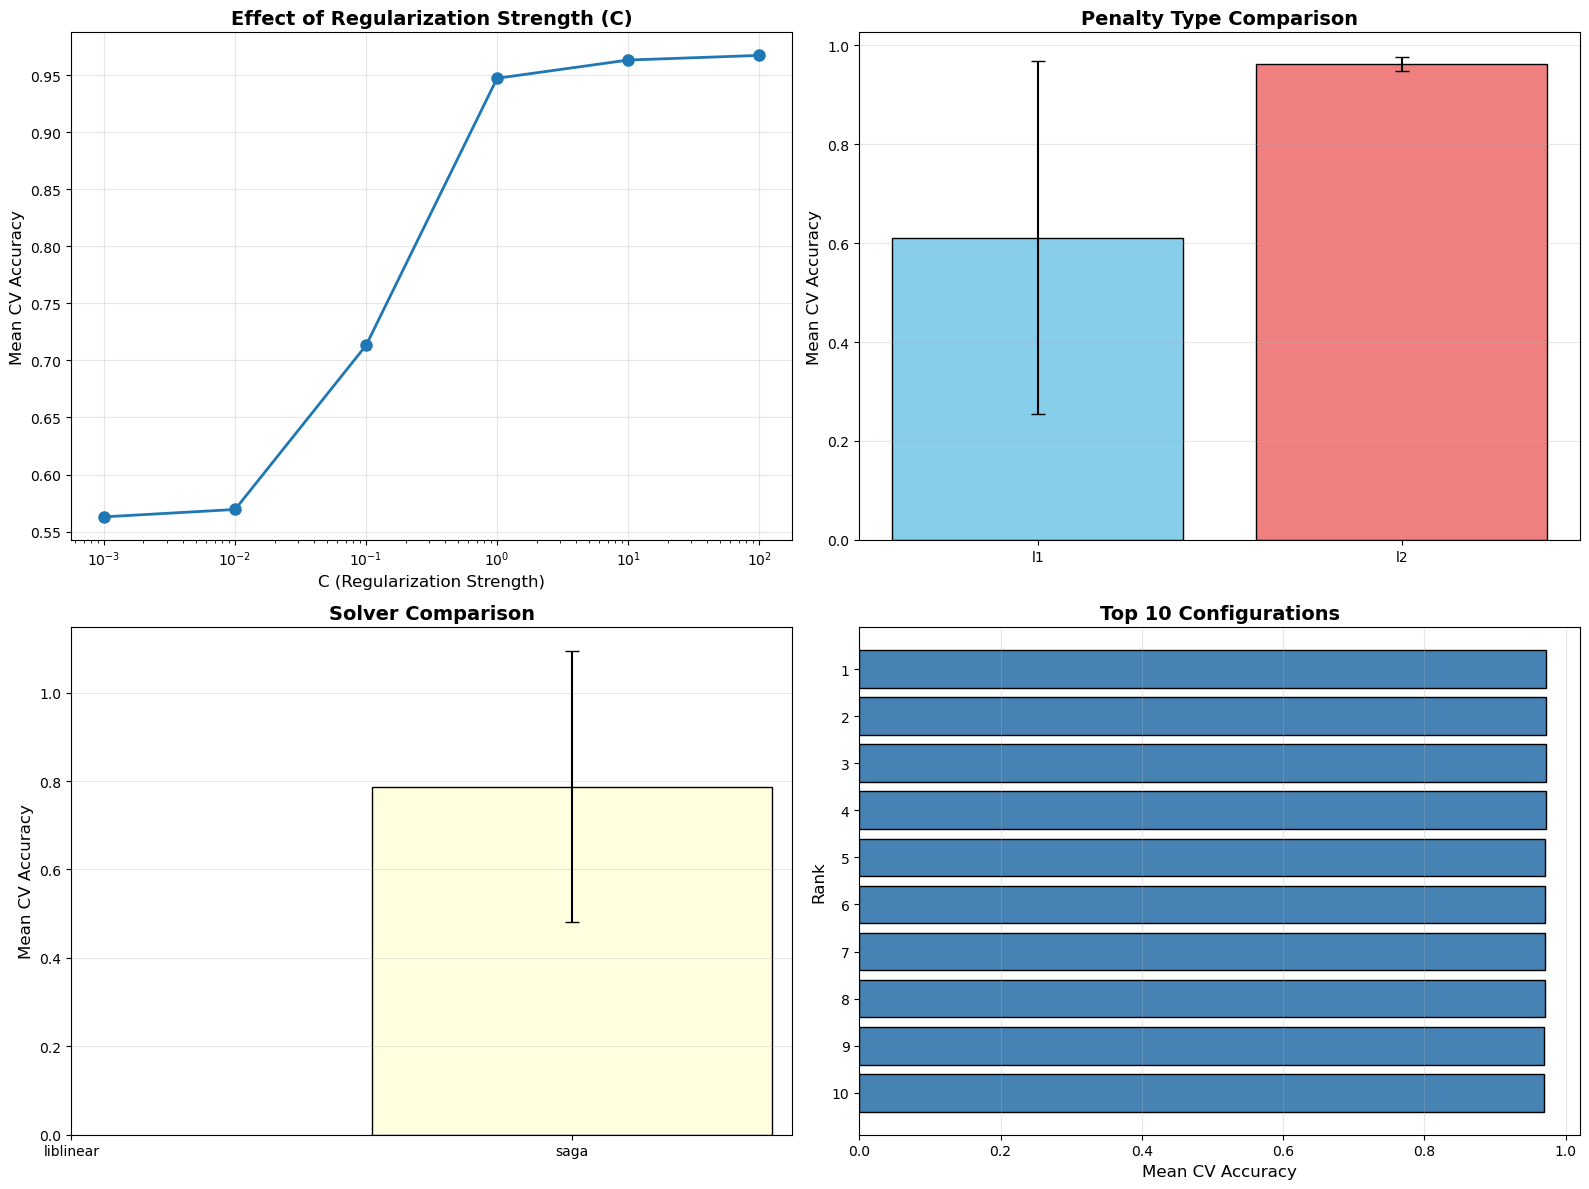

In [ ]:
# HYPERPARAMETER TUNING WITH GRIDSEARCHCV

print("\n" + "="*50)
print("HYPERPARAMETER TUNING WITH GRIDSEARCHCV")
print("="*50)

print("""
PARAMETERS TO TUNE:
1. C (Regularization strength): Controls model complexity
   - Smaller C = Stronger regularization (simpler model, prevents overfitting)
   - Larger C = Weaker regularization (more complex model, may overfit)
   - Testing range: 0.001 to 100

2. solver: Optimization algorithm
   - 'lbfgs': Good for small datasets, handles L2 penalty
   - 'saga': Handles L1, L2, and ElasticNet penalties, good for large datasets
   - 'liblinear': Good for small datasets, handles L1 and L2

3. penalty: Regularization type
   - 'l1': Lasso regularization (feature selection, sparsity)
   - 'l2': Ridge regularization (shrinks coefficients, prevents overfitting)
   - Default: 'l2' (most common for text classification)

4. max_iter: Maximum iterations for convergence
   - Higher values allow more time for optimization to converge

CROSS-VALIDATION: 5-fold stratified CV
   - Ensures each fold has balanced class distribution
   - Reliable performance estimates across different data splits
   - Standard practice for model evaluation
""")

# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 200, 500, 1000]
}

print("Parameter Grid:")
print(f"  C values: {param_grid['C']}")
print(f"  Penalties: {param_grid['penalty']}")
print(f"  Solvers: {param_grid['solver']}")
print(f"  Max iterations: {param_grid['max_iter']}")
print(f"\nTotal combinations to test: {len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver']) * len(param_grid['max_iter'])}")

# Create base model
base_model = LogisticRegression(
    multi_class='multinomial',
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

# Create GridSearchCV
print("\nStarting Grid Search with 5-Fold Cross-Validation...")
print("This will test all parameter combinations systematically.\n")

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all CPU cores
    verbose=2,  # Show progress
    return_train_score=True
)

# Fit GridSearchCV
grid_search.fit(X_train_tfidf, y_train)

# Display results
print("\n" + "="*50)
print("GRID SEARCH RESULTS")
print("="*50)

print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print(f"\nBest Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Get detailed results
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

print(f"\nTop 5 Parameter Combinations:")
print(results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head())

# Visualize Grid Search Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Effect of C on accuracy
c_scores = results_df.groupby('param_C')['mean_test_score'].mean()
axes[0, 0].plot(c_scores.index, c_scores.values, marker='o', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('C (Regularization Strength)', fontsize=12)
axes[0, 0].set_ylabel('Mean CV Accuracy', fontsize=12)
axes[0, 0].set_title('Effect of Regularization Strength (C)', fontsize=14, fontweight='bold')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Penalty comparison
penalty_scores = results_df.groupby('param_penalty')['mean_test_score'].agg(['mean', 'std'])
x_pos = np.arange(len(penalty_scores))
axes[0, 1].bar(x_pos, penalty_scores['mean'], yerr=penalty_scores['std'], 
               capsize=5, color=['skyblue', 'lightcoral'], edgecolor='black')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(penalty_scores.index)
axes[0, 1].set_ylabel('Mean CV Accuracy', fontsize=12)
axes[0, 1].set_title('Penalty Type Comparison', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Solver comparison
solver_scores = results_df.groupby('param_solver')['mean_test_score'].agg(['mean', 'std'])
x_pos = np.arange(len(solver_scores))
axes[1, 0].bar(x_pos, solver_scores['mean'], yerr=solver_scores['std'], 
               capsize=5, color=['lightgreen', 'lightyellow'], edgecolor='black')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(solver_scores.index)
axes[1, 0].set_ylabel('Mean CV Accuracy', fontsize=12)
axes[1, 0].set_title('Solver Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Top 10 configurations
top_10 = results_df.head(10).copy()
top_10['config'] = top_10.apply(lambda x: f"C={x['param_C']}, {x['param_penalty']}, {x['param_solver']}", axis=1)
axes[1, 1].barh(range(len(top_10)), top_10['mean_test_score'], color='steelblue', edgecolor='black')
axes[1, 1].set_yticks(range(len(top_10)))
axes[1, 1].set_yticklabels(range(1, len(top_10) + 1))
axes[1, 1].set_xlabel('Mean CV Accuracy', fontsize=12)
axes[1, 1].set_ylabel('Rank', fontsize=12)
axes[1, 1].set_title('Top 10 Configurations', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

In [8]:
# MODEL TRAINING WITH BEST PARAMETERS
print("\n" + "="*50)
print("FINAL MODEL TRAINING")
print("="*50)

# The best model is already trained by GridSearchCV
model = grid_search.best_estimator_

print("Model training completed with optimized hyperparameters!")
print(f"Using best model from GridSearchCV")


FINAL MODEL TRAINING
Model training completed with optimized hyperparameters!
Using best model from GridSearchCV



MODEL EVALUATION

Accuracy: 0.9798

Classification Report:
               precision    recall  f1-score   support

     business       0.99      0.96      0.98       102
entertainment       0.96      1.00      0.98        77
     politics       0.98      0.96      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.96      0.97      0.97        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



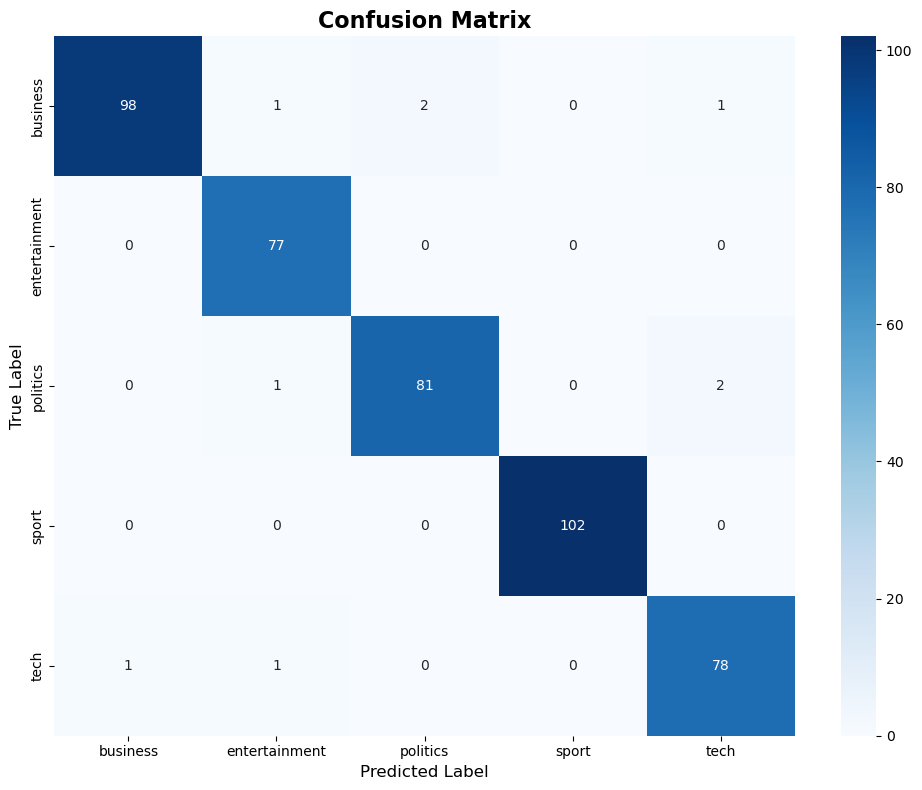


Per-class Accuracy:
  business: 0.9608
  entertainment: 1.0000
  politics: 0.9643
  sport: 1.0000
  tech: 0.9750


In [9]:
# MODEL EVALUATION

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Predictions
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class Accuracy:")
for i, class_name in enumerate(model.classes_):
    class_mask = y_test == class_name
    class_accuracy = accuracy_score(y_test[class_mask], y_pred[class_mask])
    print(f"  {class_name}: {class_accuracy:.4f}")


SHAP EXPLAINABILITY ANALYSIS

Creating SHAP explainer (this may take a few minutes)...
Calculating SHAP values for 100 samples...

Original shap_values shape: (100, 5000, 5)
Restructured SHAP values to list of 5 arrays
Final structure: 5 classes
Shape per class: (100, 5000)
X_test_sample_dense shape: (100, 5000)
✓ Shapes verified! Proceeding with visualization...


Generating SHAP summary plots...


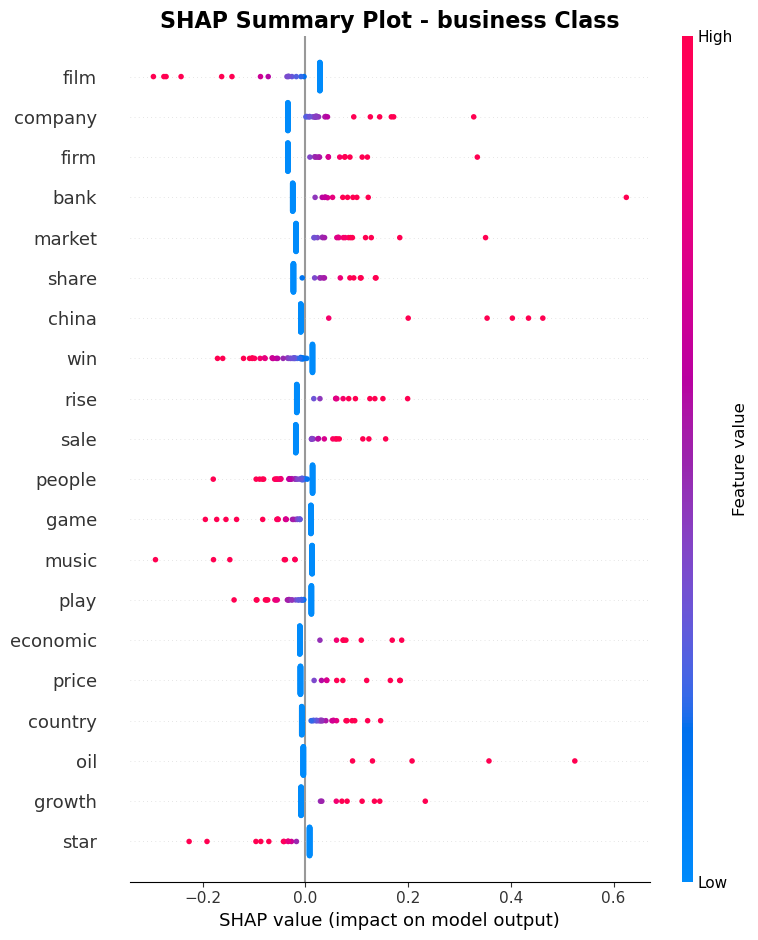

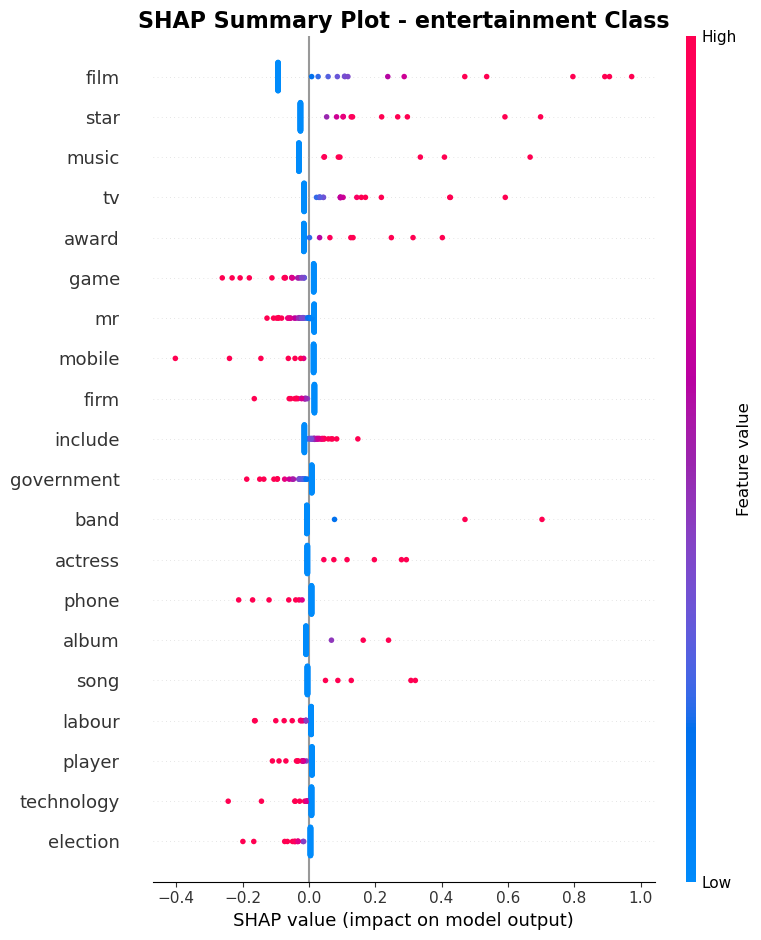

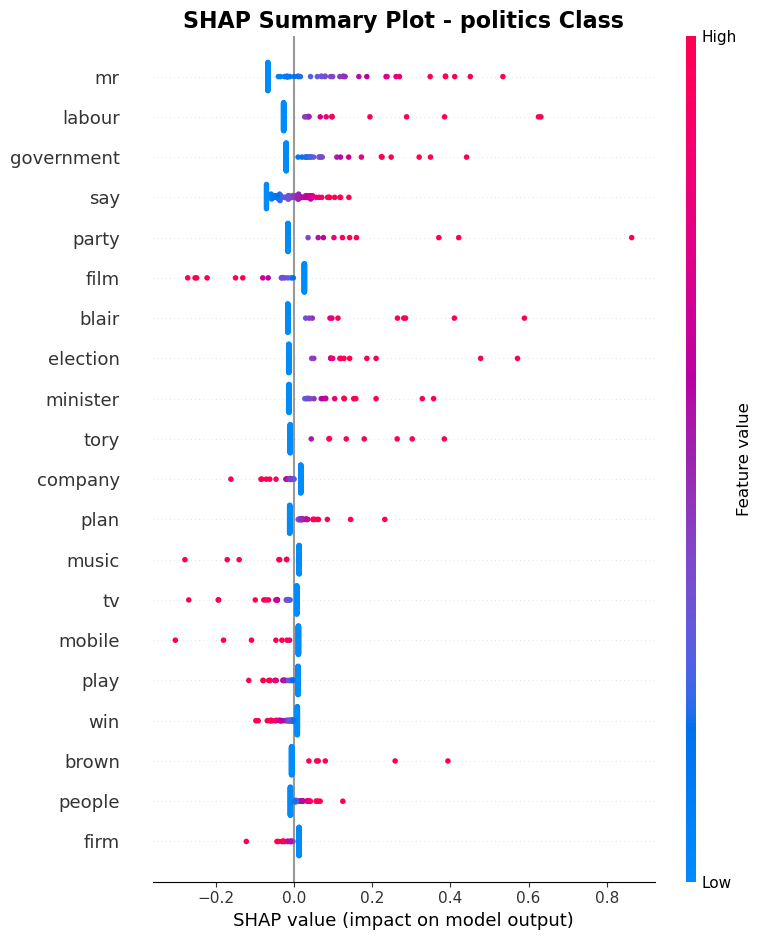

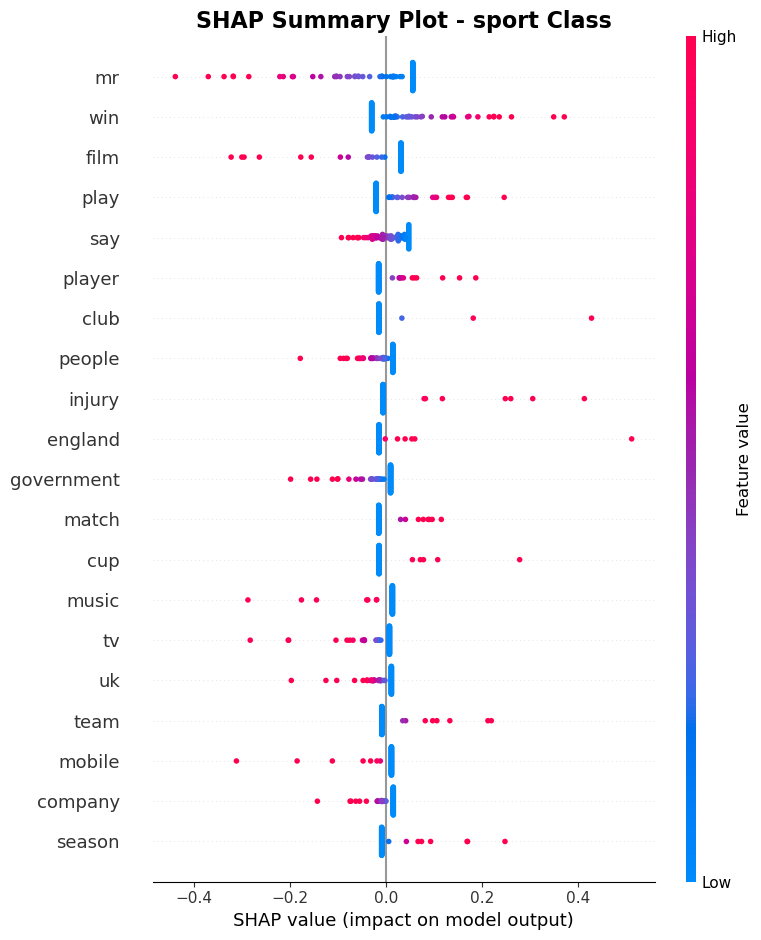

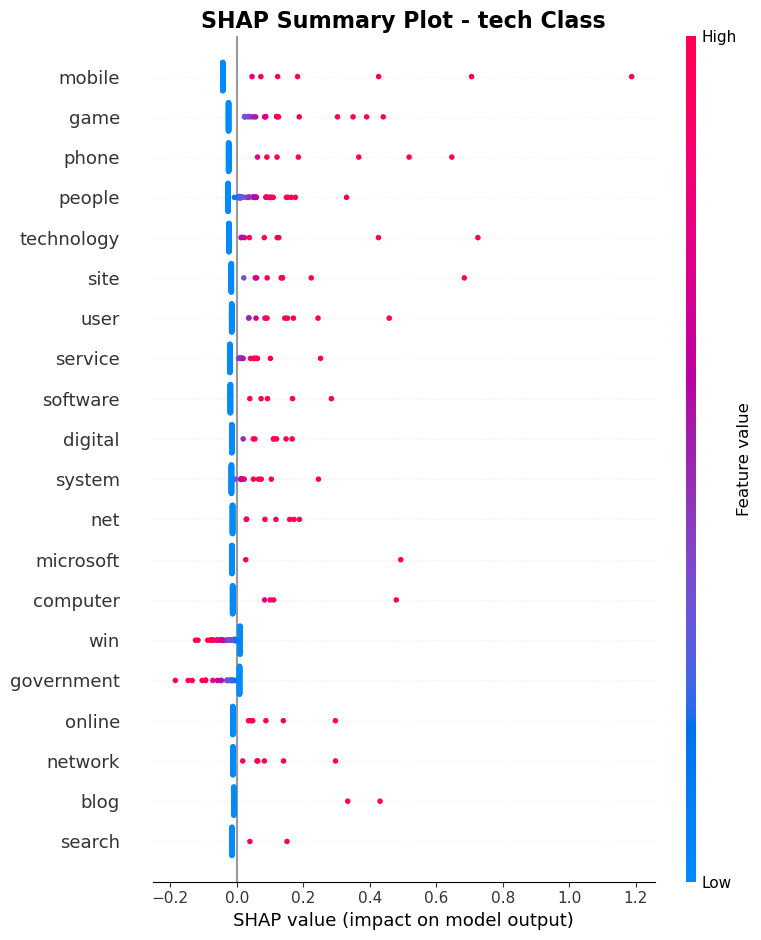


Generating SHAP feature importance plot...


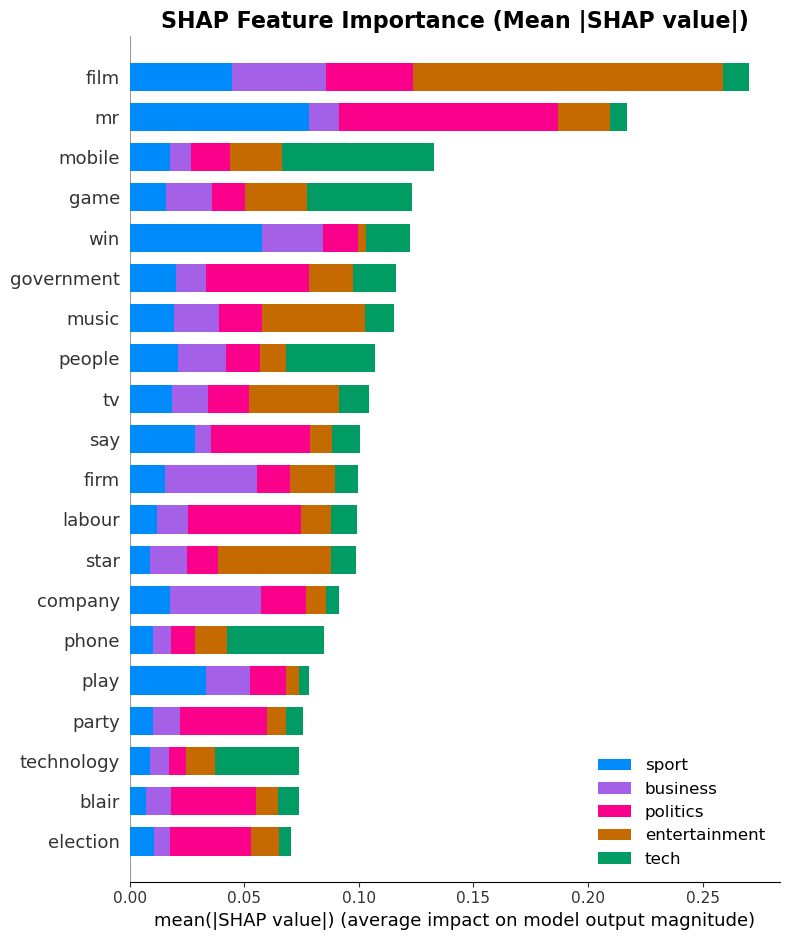


Generating individual prediction explanations...

Example Prediction:
  Text: profit jump china s bank industrial commercial bank icbc china s big lender see jump profit increase earning allow firm write bad loan pave way state ...
  True Label: business
  Predicted Label: business


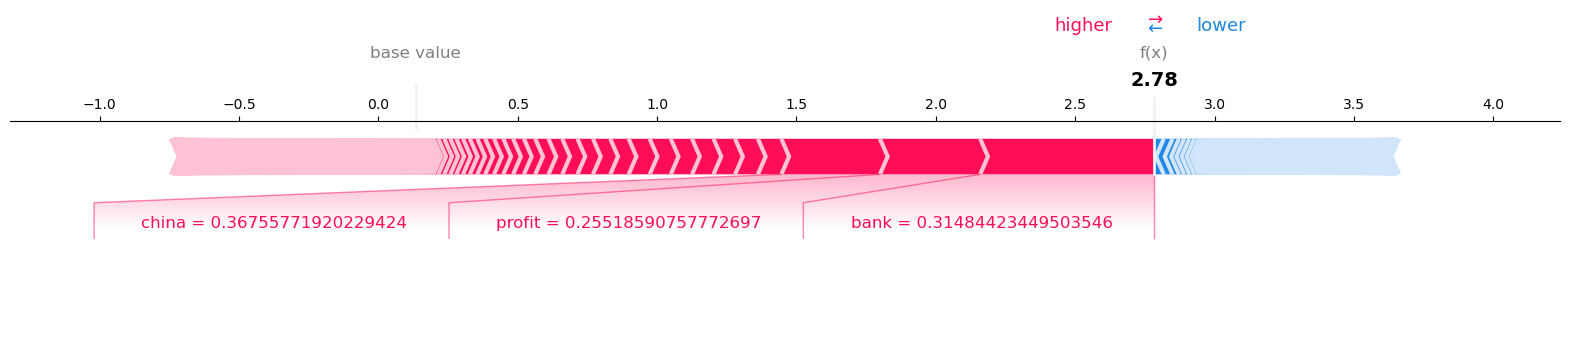

In [10]:
# SHAP EXPLAINABILITY

print("\n" + "="*50)
print("SHAP EXPLAINABILITY ANALYSIS")
print("="*50)

# Create SHAP explainer
print("\nCreating SHAP explainer (this may take a few minutes)...")
explainer = shap.LinearExplainer(
    model, 
    X_train_tfidf,
    feature_names=vectorizer.get_feature_names_out()
)

# Calculate SHAP values for test set (using subset for speed)
sample_size = min(100, len(X_test))
X_test_sample = X_test_tfidf[:sample_size]
y_test_sample = y_test.iloc[:sample_size].reset_index(drop=True)

print(f"Calculating SHAP values for {sample_size} samples...")
shap_values = explainer.shap_values(X_test_sample)

# Convert sparse matrix to dense array for SHAP plotting
X_test_sample_dense = X_test_sample.toarray()

# Fix SHAP values structure
print(f"\nOriginal shap_values shape: {shap_values.shape}")

# SHAP returns shape: (n_samples, n_features, n_classes) for multiclass
# We need to convert to list of arrays: [(n_samples, n_features) for each class]
if len(shap_values.shape) == 3:
    # Format: (samples, features, classes)
    num_classes = shap_values.shape[2]
    shap_values_list = [shap_values[:, :, i] for i in range(num_classes)]
    print(f"Restructured SHAP values to list of {num_classes} arrays")
elif len(shap_values.shape) == 2:
    # Binary classification or single output
    shap_values_list = [shap_values]
    print("Using SHAP values as-is (binary classification)")
else:
    # Unexpected format - try to handle it
    print(f"Unexpected SHAP values shape: {shap_values.shape}")
    # Assume it's already a list or similar structure
    shap_values_list = shap_values

print(f"Final structure: {len(shap_values_list)} classes")
print(f"Shape per class: {shap_values_list[0].shape}")
print(f"X_test_sample_dense shape: {X_test_sample_dense.shape}")

# Verify shapes match
assert shap_values_list[0].shape == X_test_sample_dense.shape, \
    f"Shape mismatch: SHAP {shap_values_list[0].shape} vs Data {X_test_sample_dense.shape}"

print("✓ Shapes verified! Proceeding with visualization...\n")

# Summary plot for each class
print("\nGenerating SHAP summary plots...")
for i, class_name in enumerate(model.classes_):
    plt.figure(figsize=(12, 8))
    shap.summary_plot(
        shap_values_list[i],
        X_test_sample_dense,
        feature_names=vectorizer.get_feature_names_out(),
        show=False,
        max_display=20
    )
    plt.title(f'SHAP Summary Plot - {class_name} Class', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Bar plot of mean absolute SHAP values
print("\nGenerating SHAP feature importance plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_list,
    X_test_sample_dense,
    feature_names=vectorizer.get_feature_names_out(),
    plot_type="bar",
    show=False,
    max_display=20,
    class_names=model.classes_
)
plt.title('SHAP Feature Importance (Mean |SHAP value|)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Individual prediction explanation
print("\nGenerating individual prediction explanations...")
sample_idx = 0
sample_text_original = X_test.iloc[sample_idx]
true_label = y_test.iloc[sample_idx]
pred_label = y_pred[sample_idx]

print(f"\nExample Prediction:")
print(f"  Text: {sample_text_original[:150]}...")
print(f"  True Label: {true_label}")
print(f"  Predicted Label: {pred_label}")

# Force plot for individual prediction
class_idx = np.where(model.classes_ == pred_label)[0][0]
shap.force_plot(
    explainer.expected_value[class_idx],
    shap_values_list[class_idx][sample_idx],
    X_test_sample_dense[sample_idx],
    feature_names=vectorizer.get_feature_names_out(),
    matplotlib=True,
    show=False
)
plt.show()

In [11]:

# TOP FEATURES PER CLASS

print("\n" + "="*50)
print("TOP PREDICTIVE FEATURES PER CLASS")
print("="*50)

feature_names = vectorizer.get_feature_names_out()
for i, class_name in enumerate(model.classes_):
    coefficients = model.coef_[i]
    
    # Top positive features
    top_positive_indices = np.argsort(coefficients)[-10:][::-1]
    
    print(f"\nTop 10 features for '{class_name}':")
    for idx in top_positive_indices:
        print(f"  {feature_names[idx]}: {coefficients[idx]:.4f}")


TOP PREDICTIVE FEATURES PER CLASS

Top 10 features for 'business':
  company: 2.0790
  bank: 2.0622
  firm: 1.9751
  share: 1.8384
  market: 1.7137
  price: 1.5062
  rise: 1.4750
  economic: 1.4348
  profit: 1.4329
  sale: 1.3732

Top 10 features for 'entertainment':
  film: 3.8098
  star: 2.3501
  music: 2.0952
  band: 1.7921
  singer: 1.6681
  album: 1.6201
  award: 1.5882
  tv: 1.4973
  chart: 1.3833
  song: 1.2495

Top 10 features for 'politics':
  party: 2.3515
  mr: 2.2396
  labour: 2.1105
  government: 2.0242
  minister: 1.8306
  election: 1.8201
  lord: 1.7361
  blair: 1.7020
  tory: 1.7020
  mp: 1.3857

Top 10 features for 'sport':
  win: 2.0188
  match: 1.8177
  club: 1.7452
  player: 1.6603
  coach: 1.5633
  play: 1.5126
  cup: 1.5011
  olympic: 1.4059
  champion: 1.3792
  england: 1.3410

Top 10 features for 'tech':
  game: 2.3939
  computer: 2.2566
  technology: 2.0720
  software: 2.0516
  user: 1.8971
  mobile: 1.8844
  online: 1.7946
  people: 1.7006
  phone: 1.6836
  d

In [12]:
# PREDICTION FUNCTION

def predict_news_category(text, show_probabilities=True):
    """
    Predict category for new text
    """
    processed = preprocess_text(text)
    vectorized = vectorizer.transform([processed])
    prediction = model.predict(vectorized)[0]
    
    if show_probabilities:
        probabilities = model.predict_proba(vectorized)[0]
        print(f"\nText: {text[:100]}...")
        print(f"Predicted Category: {prediction}")
        print("\nProbabilities:")
        for class_name, prob in zip(model.classes_, probabilities):
            print(f"  {class_name}: {prob:.4f}")
    
    return prediction

# Example predictions
print("\n" + "="*50)
print("EXAMPLE PREDICTIONS")
print("="*50)

example_texts = [
    "The stock market rallied today as investors responded positively to economic data showing strong growth in the technology sector.",
    "The football team won the championship after a thrilling final match that went into overtime.",
    "Scientists discovered a new species in the Amazon rainforest with unique characteristics."
]

for text in example_texts:
    predict_news_category(text)
    print()


EXAMPLE PREDICTIONS

Text: The stock market rallied today as investors responded positively to economic data showing strong gro...
Predicted Category: business

Probabilities:
  business: 0.6936
  entertainment: 0.0687
  politics: 0.0498
  sport: 0.0652
  tech: 0.1227


Text: The football team won the championship after a thrilling final match that went into overtime....
Predicted Category: sport

Probabilities:
  business: 0.0182
  entertainment: 0.0245
  politics: 0.0142
  sport: 0.9235
  tech: 0.0195


Text: Scientists discovered a new species in the Amazon rainforest with unique characteristics....
Predicted Category: entertainment

Probabilities:
  business: 0.1962
  entertainment: 0.2253
  politics: 0.1600
  sport: 0.2007
  tech: 0.2177



In [13]:
#  MODEL SUMMARY

print("="*50)
print("PROJECT COMPLETE!")
print("="*50)
print("\nModel Summary:")
print(f"  Algorithm: Multinomial Logistic Regression")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")
print(f"  Number of features: {X_train_tfidf.shape[1]}")
print(f"  Number of classes: {len(model.classes_)}")
print(f"  Best CV Accuracy: {grid_search.best_score_:.4f}")
print(f"  Test Accuracy: {accuracy:.4f}")

print("\nOptimized Hyperparameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

PROJECT COMPLETE!

Model Summary:
  Algorithm: Multinomial Logistic Regression
  Training samples: 1780
  Test samples: 445
  Number of features: 5000
  Number of classes: 5
  Best CV Accuracy: 0.9719
  Test Accuracy: 0.9798

Optimized Hyperparameters:
  C: 1
  max_iter: 100
  penalty: l2
  solver: saga
